# --------------------- Model Training, Evaluation & Validation ---------------------

####

# Project plan

#### Importing important packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

######

#### Importing cleaned dataset which earlier saved in pickle file

In [2]:
df = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\df.pkl")
train_x = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\train_x.pkl")
train_y = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\train_y.pkl")
test_x = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\test_x.pkl")
test_y = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\test_y.pkl")

######

# Model 1: Logistics Regression

In [8]:
# Model creation

LR = LogisticRegression(penalty='l2',dual=False,tol=0.0001,C=1.0,fit_intercept=True,
                        intercept_scaling=1,class_weight=None,random_state=None,solver='lbfgs',
                        max_iter=100,multi_class='deprecated',verbose=0,warm_start=False,n_jobs=None,l1_ratio=None)

LR.fit(train_x, train_y)

LogisticRegression()

In [9]:
# Predicting for train and test data

df_LR_train = pd.DataFrame({'Actual': train_y, 'Predicted': LR.predict(train_x)})
df_LR_test = pd.DataFrame({'Actual': test_y, 'Predicted': LR.predict(test_x)})

In [10]:
# Label encoding for y_variable

LE = LabelEncoder()

df_LR_test['Actual'] = LE.fit_transform(df_LR_test['Actual'])
df_LR_test['Predicted'] = LE.fit_transform(df_LR_test['Predicted'])


df_LR_train['Actual'] = LE.fit_transform(df_LR_train['Actual'])
df_LR_train['Predicted'] = LE.fit_transform(df_LR_train['Predicted'])

# Errors

In [11]:
# Classification report of Train data for Logistics regression

print(classification_report(df_LR_train.Actual, df_LR_train.Predicted))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75     12160
           1       0.75      0.76      0.75     12160

    accuracy                           0.75     24320
   macro avg       0.75      0.75      0.75     24320
weighted avg       0.75      0.75      0.75     24320



In [12]:
# Classification report of Test data for Logistics regression

print(classification_report(df_LR_test.Actual, df_LR_test.Predicted))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      5275
           1       0.32      0.73      0.44       864

    accuracy                           0.74      6139
   macro avg       0.63      0.74      0.64      6139
weighted avg       0.86      0.74      0.78      6139



In [13]:
print('roc auc score of train data',roc_auc_score(df_LR_train.Actual, df_LR_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_LR_test.Actual, df_LR_test.Predicted))

print("")

roc auc score of train data 0.7491776315789473
roc auc score of test data 0.73799817886607



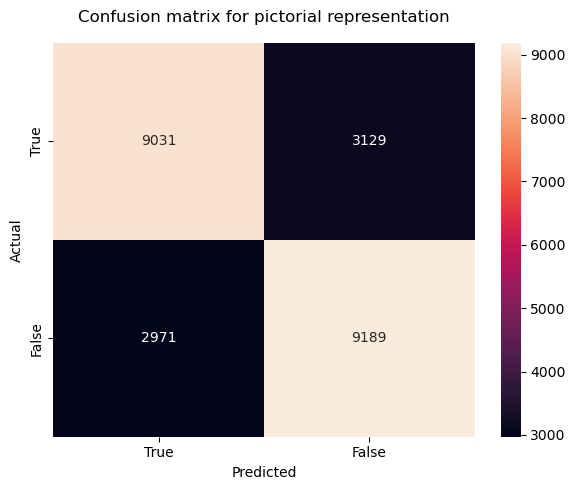

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_LR_train.Actual, df_LR_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

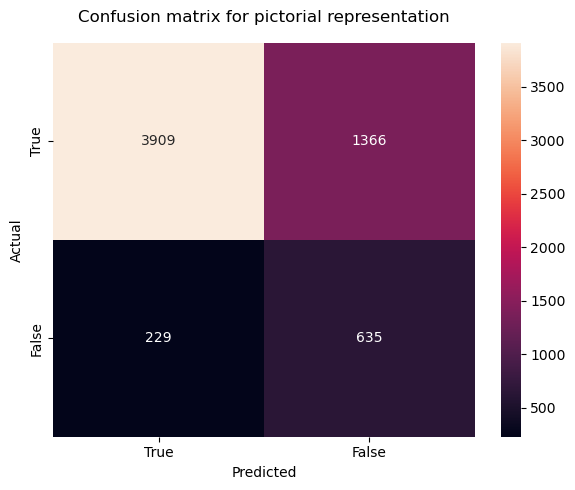

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_LR_test.Actual, df_LR_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Model 2: RandomForest

In [17]:
# Model creation

rf = RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=None,min_samples_split=2,
                       min_samples_leaf=1,min_weight_fraction_leaf=0.0,max_features='sqrt',
                       max_leaf_nodes=None,min_impurity_decrease=0.0,bootstrap=True,oob_score=False,
                       n_jobs=None,random_state=None,verbose=0,warm_start=False,class_weight=None,
                       ccp_alpha=0.0,max_samples=None,monotonic_cst=None)

rf.fit(train_x, train_y)

RandomForestClassifier()

In [18]:
df_rf_train = pd.DataFrame({'Actual': train_y, 'Predicted': rf.predict(train_x)})
df_rf_test = pd.DataFrame({'Actual': test_y, 'Predicted': rf.predict(test_x)})

# Errors

In [19]:
# Classification report of Train data for RandomForest

print(classification_report(df_rf_train.Actual, df_rf_train.Predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12160
           1       1.00      1.00      1.00     12160

    accuracy                           1.00     24320
   macro avg       1.00      1.00      1.00     24320
weighted avg       1.00      1.00      1.00     24320



In [21]:
# Classification report of Test data for RandomForest

print(classification_report(df_rf_test.Actual, df_rf_test.Predicted))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93      5275
           1       0.64      0.21      0.32       864

    accuracy                           0.87      6139
   macro avg       0.76      0.60      0.62      6139
weighted avg       0.85      0.87      0.84      6139



In [22]:
print('roc auc score of train data',roc_auc_score(df_rf_train.Actual, df_rf_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_rf_test.Actual, df_rf_test.Predicted))

print("")

roc auc score of train data 1.0
roc auc score of test data 0.5950771239248728



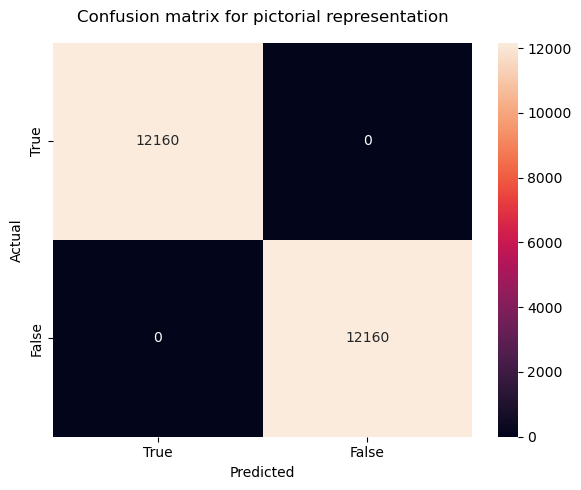

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_rf_train.Actual, df_rf_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

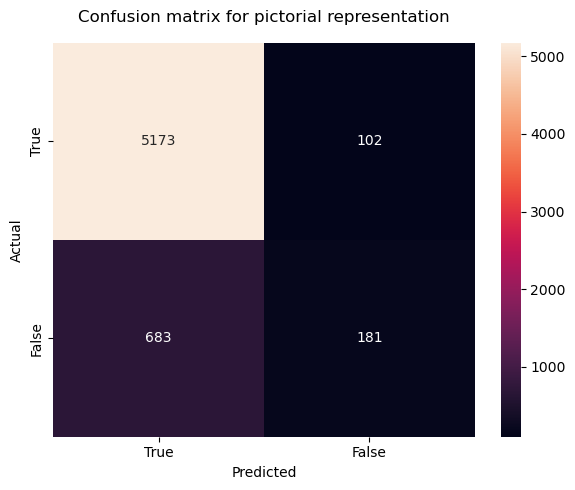

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_rf_test.Actual, df_rf_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

###
### Model 3: XGBoost

In [27]:
# Model creation

xg = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None)
xg.fit(train_x, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
df_xg_train = pd.DataFrame({'Actual': train_y, 'Predicted': xg.predict(train_x)})
df_xg_test = pd.DataFrame({'Actual': test_y, 'Predicted': xg.predict(test_x)})

# Errors

In [29]:
# Classification report of Train data for XGBoost

print(classification_report(df_xg_train.Actual, df_xg_train.Predicted))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     12160
           1       0.98      0.99      0.99     12160

    accuracy                           0.99     24320
   macro avg       0.99      0.99      0.99     24320
weighted avg       0.99      0.99      0.99     24320



In [30]:
# Classification report of Test data for XGBoost

print(classification_report(df_xg_test.Actual, df_xg_test.Predicted))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      5275
           1       0.43      0.48      0.45       864

    accuracy                           0.84      6139
   macro avg       0.67      0.69      0.68      6139
weighted avg       0.84      0.84      0.84      6139



In [31]:
print('roc auc score of train data',roc_auc_score(df_xg_train.Actual, df_xg_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_xg_test.Actual, df_xg_test.Predicted))

print("")

roc auc score of train data 0.9860197368421053
roc auc score of test data 0.6876601720203616



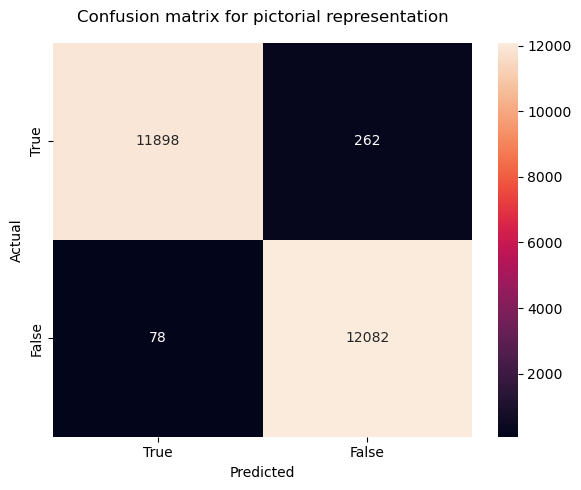

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_xg_train.Actual, df_xg_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

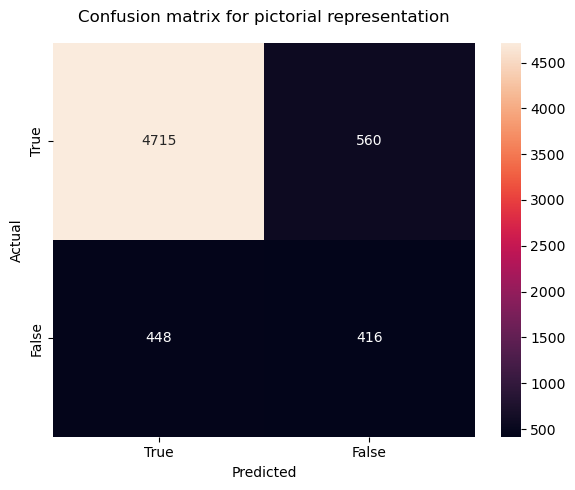

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_xg_test.Actual, df_xg_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Model 4: KNN

In [36]:
# Model creation

knn = KNeighborsClassifier()
knn.fit(train_x, train_y)

KNeighborsClassifier()

In [37]:
df_knn_train = pd.DataFrame({'Actual': train_y, 'Predicted': knn.predict(train_x)})
df_knn_test = pd.DataFrame({'Actual': test_y, 'Predicted': knn.predict(test_x)})

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

# Errors

In [38]:
# Classification report of Train data for KNN

print(classification_report(df_knn_train.Actual, df_knn_train.Predicted))

              precision    recall  f1-score   support

           0       0.99      0.79      0.88     12160
           1       0.83      0.99      0.90     12160

    accuracy                           0.89     24320
   macro avg       0.91      0.89      0.89     24320
weighted avg       0.91      0.89      0.89     24320



In [39]:
# Classification report of Test data for KNN

print(classification_report(df_knn_test.Actual, df_knn_test.Predicted))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      5275
           1       0.18      0.41      0.25       864

    accuracy                           0.66      6139
   macro avg       0.53      0.55      0.51      6139
weighted avg       0.78      0.66      0.70      6139



In [40]:
print('roc auc score of train data',roc_auc_score(df_knn_train.Actual, df_knn_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_knn_test.Actual, df_knn_test.Predicted))

print("")

roc auc score of train data 0.8918996710526316
roc auc score of test data 0.5537710637177462



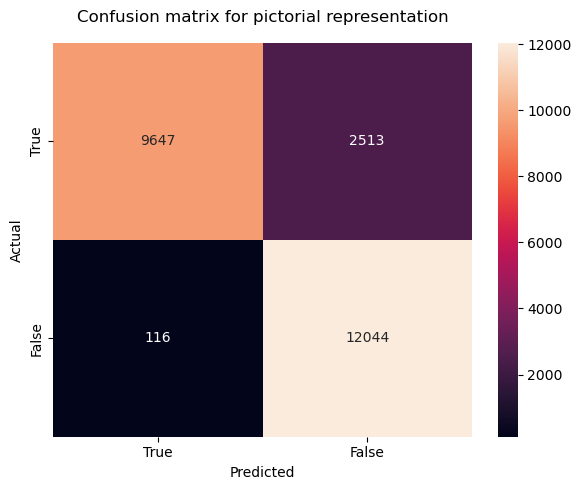

In [41]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_knn_train.Actual, df_knn_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

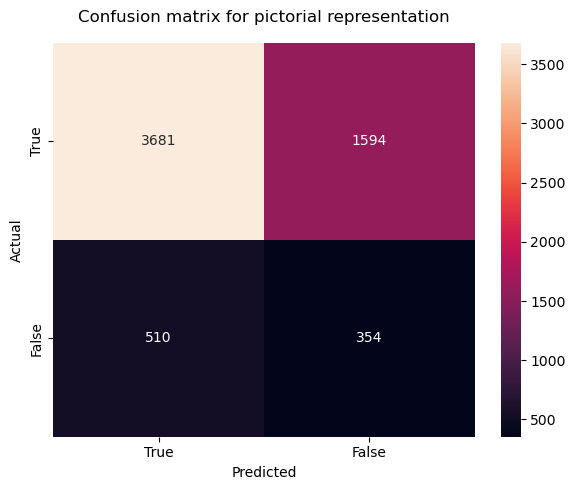

In [42]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_knn_test.Actual, df_knn_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [43]:
# Not running SVC coz it will too much time for this dataset (large dataset)

In [46]:
from sklearn.svm import SVC

In [47]:
# Model creation

sv = SVC()
sv.fit(train_x, train_y)

SVC()

In [55]:
df_sv_train = pd.DataFrame({'Actual': train_y, 'Predicted': sv.predict(train_x)})
df_sv_test = pd.DataFrame({'Actual': test_y, 'Predicted': sv.predict(test_x)})

In [56]:
# Errors

In [57]:
# Classification report of Train data

print(classification_report(df_sv_train.Actual, df_sv_train.Predicted))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67     12160
           1       1.00      0.01      0.02     12160

    accuracy                           0.51     24320
   macro avg       0.75      0.51      0.35     24320
weighted avg       0.75      0.51      0.35     24320



In [58]:
# Classification report of Test data

print(classification_report(df_sv_test.Actual, df_sv_test.Predicted))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      5275
           1       1.00      0.00      0.00       864

    accuracy                           0.86      6139
   macro avg       0.93      0.50      0.46      6139
weighted avg       0.88      0.86      0.79      6139



In [59]:
print('roc auc score of train data',roc_auc_score(df_sv_train.Actual, df_sv_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_sv_test.Actual, df_sv_test.Predicted))

print("")

roc auc score of train data 0.5055921052631579
roc auc score of test data 0.5005787037037037



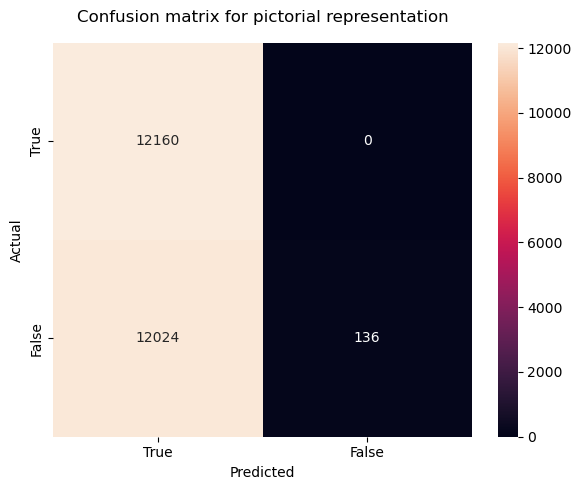

In [60]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_sv_train.Actual, df_sv_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

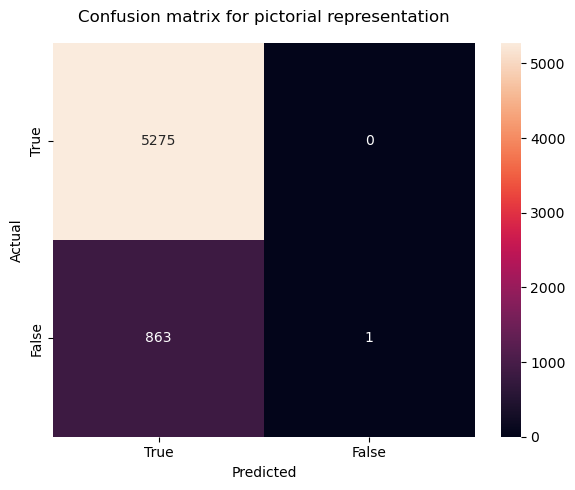

In [61]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_sv_test.Actual, df_sv_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Model 6: Gradient Boost

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

In [65]:
# Model creation

gb = GradientBoostingClassifier(random_state=42)
gb.fit(train_x, train_y)

GradientBoostingClassifier(random_state=42)

In [66]:
df_gb_train = pd.DataFrame({'Actual': train_y, 'Predicted': gb.predict(train_x)})
df_gb_test = pd.DataFrame({'Actual': test_y, 'Predicted': gb.predict(test_x)})

# # Errors

In [67]:
# Classification report of Train data

print(classification_report(df_gb_train.Actual, df_gb_train.Predicted))

              precision    recall  f1-score   support

           0       0.80      0.77      0.78     12160
           1       0.78      0.80      0.79     12160

    accuracy                           0.79     24320
   macro avg       0.79      0.79      0.79     24320
weighted avg       0.79      0.79      0.79     24320



In [68]:
# Classification report of Test data

print(classification_report(df_gb_test.Actual, df_gb_test.Predicted))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84      5275
           1       0.34      0.75      0.46       864

    accuracy                           0.76      6139
   macro avg       0.64      0.75      0.65      6139
weighted avg       0.86      0.76      0.79      6139



In [69]:
print('roc auc score of train data',roc_auc_score(df_gb_train.Actual, df_gb_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_gb_test.Actual, df_gb_test.Predicted))

print("")

roc auc score of train data 0.7870888157894737
roc auc score of test data 0.7524207916447253



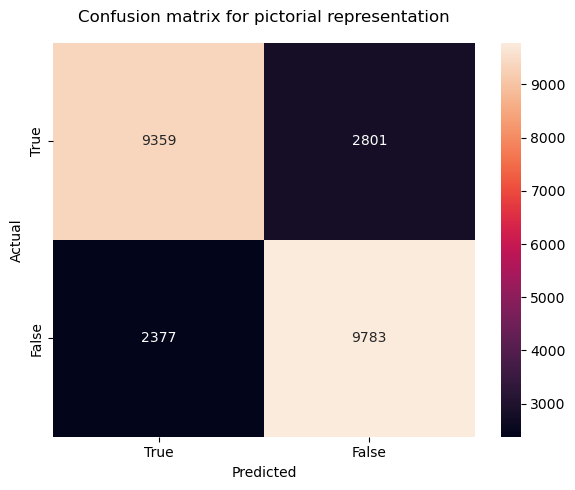

In [70]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_train.Actual, df_gb_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

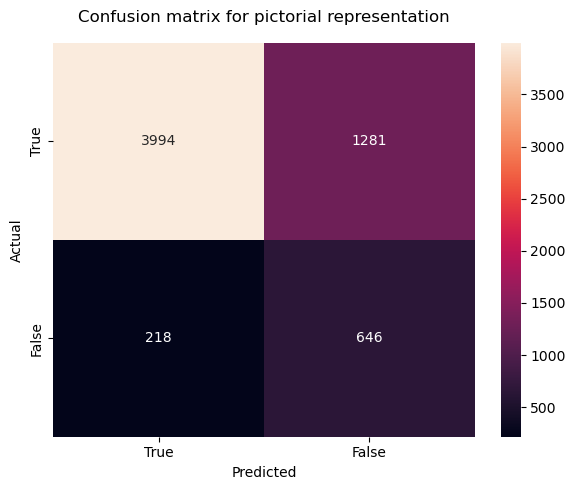

In [71]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_test.Actual, df_gb_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [72]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# List of model result DataFrames
models = {
    'Logistic Regression - Train': df_LR_train,
    'Logistic Regression - Test': df_LR_test,
    'Random Forest - Train': df_rf_train,
    'Random Forest - Test': df_rf_test,
    'XGBoost - Train': df_xg_train,
    'XGBoost - Test': df_xg_test,
    'KNN - Train': df_knn_train,
    'KNN - Test': df_knn_test,
    'Gradient Boosting - Train': df_gb_train,
    'Gradient Boosting - Test': df_gb_test
}

results = []

for model_name, df in models.items():

    precision, recall, f1, support = precision_recall_fscore_support(
        df['Actual'],
        df['Predicted'],
        labels=[1]
    )

    results.append({
        'Model': model_name,
        'Class 1 Precision': precision[0],
        'Class 1 Recall': recall[0],
        'Class 1 F1': f1[0]
    })

model_comparison = pd.DataFrame(results)

model_comparison

,Model,Class 1 Precision,Class 1 Recall,Class 1 F1
0,Logistic Regression - Train,0.745981,0.755674,0.750797
1,Logistic Regression - Test,0.317341,0.734954,0.443281
2,Random Forest - Train,1.000000,1.000000,1.000000
3,Random Forest - Test,0.639576,0.209491,0.315606
4,XGBoost - Train,0.978775,0.993586,0.986125
5,XGBoost - Test,0.426230,0.481481,0.452174
6,KNN - Train,0.827368,0.990461,0.901598
7,KNN - Test,0.181725,0.409722,0.251778
8,Gradient Boosting - Train,0.777416,0.804523,0.790737
9,Gradient Boosting - Test,0.335236,0.747685,0.462917


#  Hyperparameter Tuning

In [73]:
# Model creation

param_gb = { 'n_estimators': [200, 300, 400, 500], 'learning_rate': [0.01, 0.05, 0.10], 'max_depth': [2, 3, 4, 5] }
tuned_gb = GridSearchCV( GradientBoostingClassifier(random_state=42), param_gb, verbose=True, cv=4 )
tuned_gb.fit(train_x, train_y)
tuned_gb.best_params_

Fitting 4 folds for each of 1 candidates, totalling 4 fits


{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

In [82]:
df_gb_train_tuned = pd.DataFrame({'Actual': train_y, 'Predicted': tuned_gb.predict(train_x)})
df_gb_test_tuned = pd.DataFrame({'Actual': test_y, 'Predicted': tuned_gb.predict(test_x)})

# Errors

In [83]:
# Classification report of Train data

print(classification_report(df_gb_train_tuned.Actual, df_gb_train_tuned.Predicted))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87     12160
           1       0.86      0.90      0.88     12160

    accuracy                           0.87     24320
   macro avg       0.87      0.87      0.87     24320
weighted avg       0.87      0.87      0.87     24320



In [84]:
# Classification report of Test data

print(classification_report(df_gb_test_tuned.Actual, df_gb_test_tuned.Predicted))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87      5275
           1       0.37      0.68      0.48       864

    accuracy                           0.79      6139
   macro avg       0.65      0.74      0.67      6139
weighted avg       0.86      0.79      0.81      6139



In [85]:
print('roc auc score of train data',roc_auc_score(df_gb_train_tuned.Actual, df_gb_train_tuned.Predicted))
print('roc auc score of test data',roc_auc_score(df_gb_test_tuned.Actual, df_gb_test_tuned.Predicted))

print("")

roc auc score of train data 0.8739720394736843
roc auc score of test data 0.7447527207302089



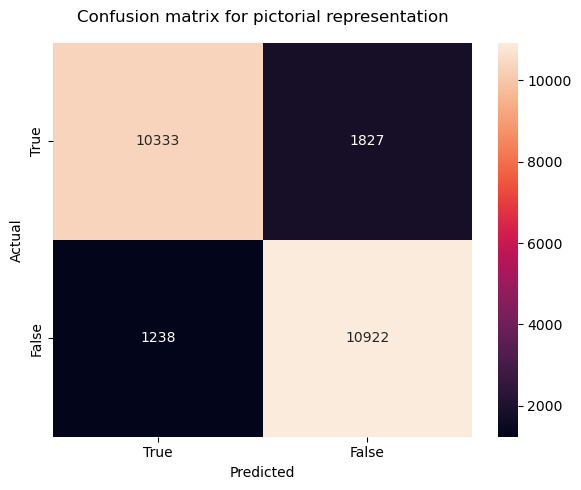

In [86]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_train_tuned.Actual, df_gb_train_tuned.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

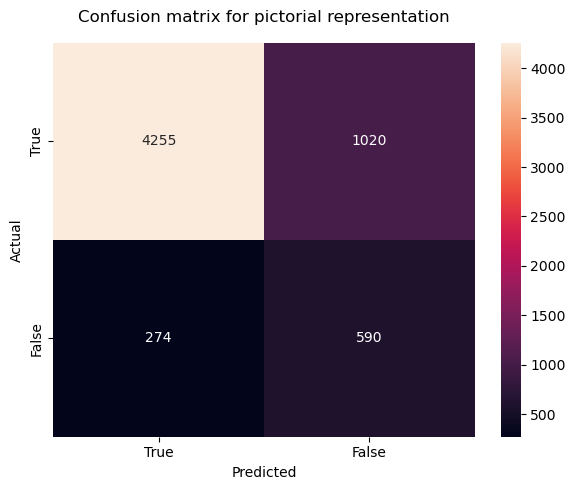

In [87]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_test_tuned.Actual, df_gb_test_tuned.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### 
#### After comparing multiple classification models, Gradient Boosting was selected 
#### for hyperparameter tuning. The tuned model achieved an F1-score of 0.480 on the 
#### test set, with 0.370 precision and 0.680 recall for late shipments.

####
# Decile analysis

In [107]:
df_gb_train_tuned["prob"] = tuned_gb.predict_proba(train_x)[:, 1]
df_gb_test_tuned["prob"] = tuned_gb.predict_proba(test_x)[:, 1]

df_gb_train_tuned = df_gb_train_tuned.sort_values(by="prob", ascending=False).reset_index(drop=True)

df_gb_train_tuned["Decile"] = pd.qcut(df_gb_train_tuned["prob"],q=10,labels=False,duplicates="drop") + 1

In [118]:
decile_analysis = (df_gb_train_tuned.groupby("Decile").agg(Count=("Actual", "size"), Actual_Late=("Actual", "sum"),
                    Actual_Late_Rate=("Actual", "mean"), Avg_Predicted_Probability=("prob", "mean")).reset_index())

decile_analysis["Actual_Late_Rate"] *= 100
decile_analysis["Avg_Predicted_Probability"] *= 100

decile_analysis

,Decile,Count,Actual_Late,Actual_Late_Rate,Avg_Predicted_Probability
0,1,2432,1925,79.152961,6.602365
1,2,2432,1894,77.878289,12.154792
2,3,2432,1887,77.590461,19.154944
3,4,2433,1692,69.543773,30.608982
4,5,2431,1431,58.864665,45.889294
5,6,2432,968,39.802632,59.473738
6,7,2433,729,29.963009,70.302629
7,8,2435,603,24.763860,78.666827
8,9,2429,553,22.766571,85.257501
9,10,2431,478,19.662690,91.918568


# Decile Analysis

The decile analysis shows a clear and consistent relationship between the model's predicted probability of late delivery and the actual late-delivery rate. 

The highest-risk group (Decile 1) has an actual late-delivery rate of approximately **79.15%**, while the lowest-risk group (Decile 10) has an actual late-delivery rate of approximately **19.66%**.

As the predicted probability of late delivery increases, the actual late-delivery rate generally increases as well. 
This indicates that the Gradient Boosting model is effective at **ranking shipments according to their relative risk of late delivery**.

The results demonstrate good discriminatory and ranking capability, as shipments assigned higher predicted probabilities tend to have substantially higher observed late-delivery rates.


In [80]:
import pickle

# Creating a pickle of the best model
final_model = tuned_gb.best_estimator_

with open(
    "C:/Users/Naveen/Desktop/GitHub/TransGlobe_Business/Classification_model/final_model.pkl",
    "wb"
) as file:
    pickle.dump(final_model, file)

# ------------------------------------------- End -------------------------------------------